### Data Import Test

Logistic Regression - Sag - Iterations: [12]


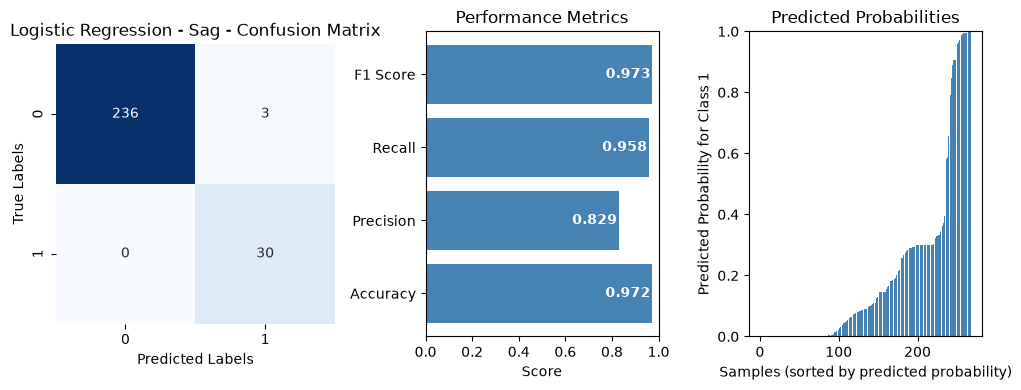

Logistic Regression - Sag_harmonics - Iterations: [11]


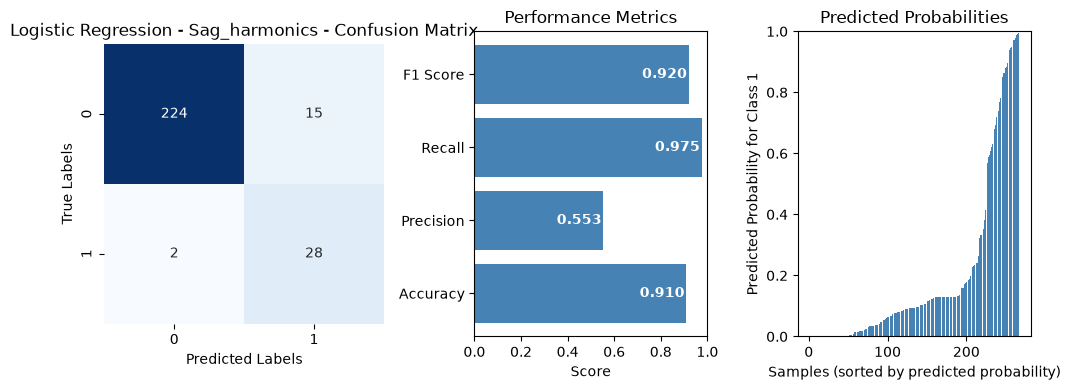

Logistic Regression - Transient - Iterations: [12]


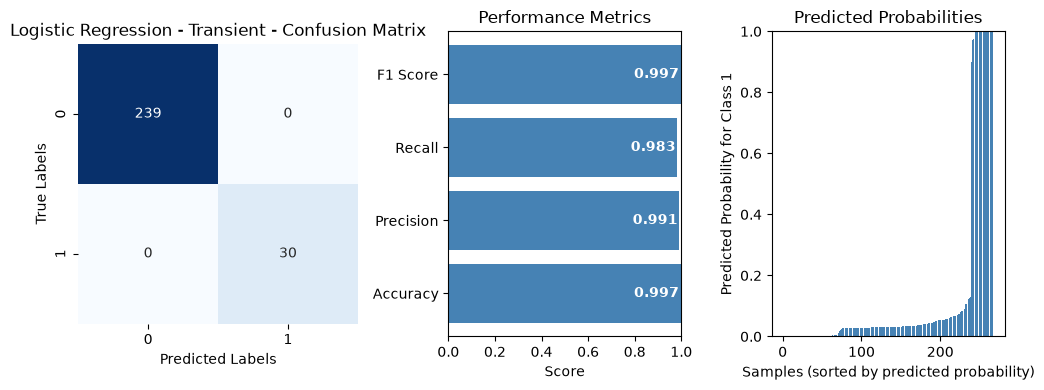

Logistic Regression - Swell_harmonics - Iterations: [13]


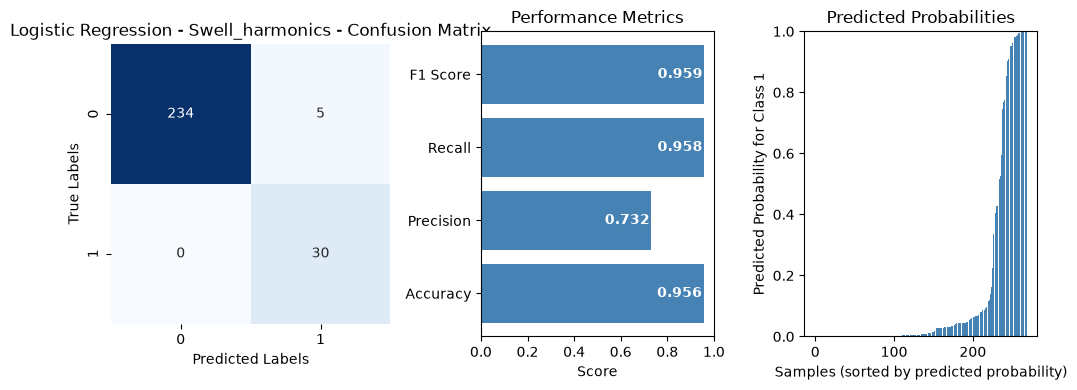

Logistic Regression - Normal - Iterations: [11]


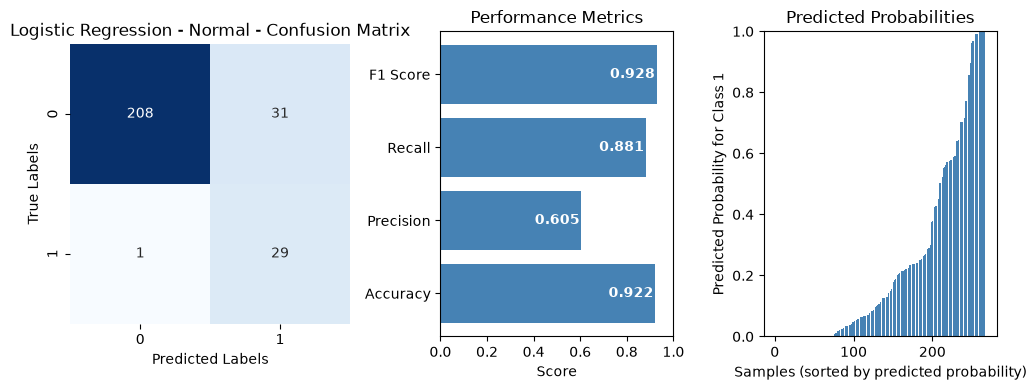

Logistic Regression - Flicker - Iterations: [9]


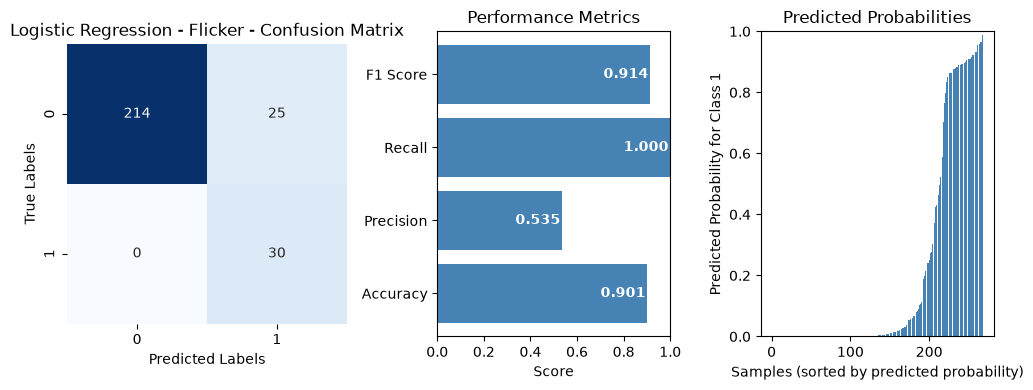

Logistic Regression - Harmonics - Iterations: [11]


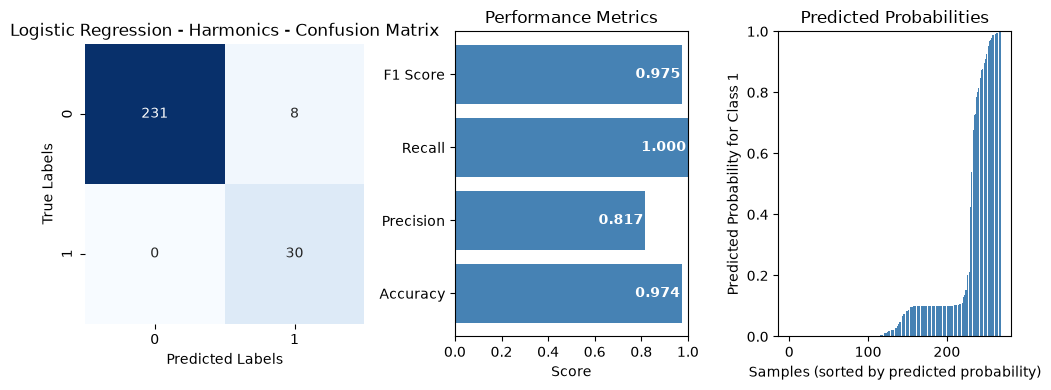

Logistic Regression - Swell - Iterations: [11]


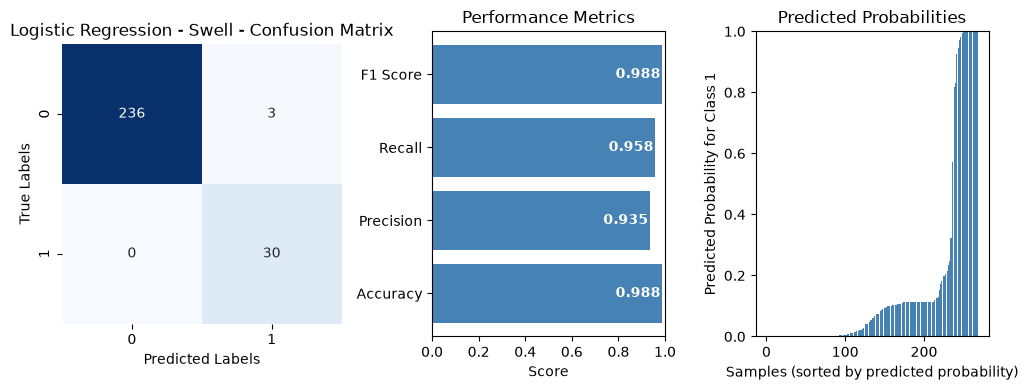

Logistic Regression - Interruption - Iterations: [11]


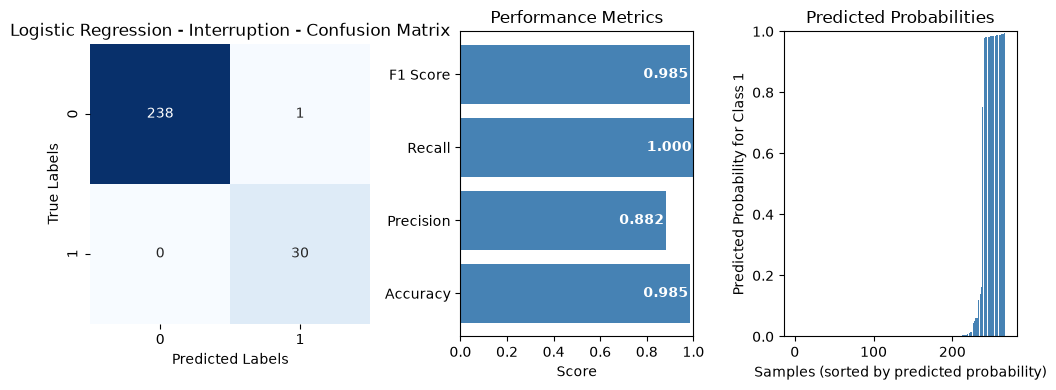

      Target Label  Accuracy  Precision    Recall  F1 Score
2        Transient  0.997199   0.991453  0.983120  0.997194
7            Swell  0.987872   0.935123  0.957906  0.987957
8     Interruption  0.985074   0.881606  1.000000  0.985483
6        Harmonics  0.973890   0.816552  1.000000  0.975293
0              Sag  0.972031   0.829433  0.958120  0.973178
3  Swell_harmonics  0.956168   0.731985  0.958120  0.958732
4           Normal  0.921626   0.605272  0.881410  0.927886
1    Sag_harmonics  0.909509   0.553456  0.975000  0.919795
5          Flicker  0.901090   0.535442  1.000000  0.913668


In [1]:
from import_data import data_import
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from classifier import Classifier
import matplotlib.pyplot as plt
import pandas as pd

files = ["SNR_noiseless"]

#       Target Label          Best Feature to Drop  F1 Score   Features to Use
# 0              Sag          [F4, F1, F2, F6, F7]  0.976356      [F3, F5, F8]
# 1    Sag_harmonics              [F1, F3, F8, F4]  0.917180  [F2, F5, F6, F7]
# 2        Transient      [F1, F3, F5, F2, F8, F4]  0.998135          [F6, F7]
# 3  Swell_harmonics          [F1, F8, F2, F6, F5]  0.965709      [F3, F4, F7]
# 4           Normal      [F6, F3, F5, F2, F8, F1]  0.919926          [F4, F7]
# 5          Flicker          [F7, F5, F8, F2, F3]  0.908343      [F1, F4, F6]
# 6        Harmonics      [F5, F6, F3, F8, F4, F2]  0.977799          [F1, F7]
# 7            Swell      [F1, F3, F8, F6, F4, F5]  0.986117          [F2, F7]
# 8     Interruption  [F1, F4, F6, F2, F5, F7, F3]  0.988161              [F8]

features = ["F1", "F2", "F3", "F4", "F5", "F6", "F7", "F8"] 



features_sag = ["F3", "F5", "F8"]
feature_sag_harm = ["F2", "F5", "F6", "F7"]
features_tran = ["F6", "F7"]
features_swell_harm = ["F3", "F4", "F7"]
features_normal = ["F4", "F7"]
features_flicker = ["F1", "F4", "F6"]
features_harmonics = ["F1", "F7"]
features_swell = ["F2", "F7"]
features_interruptions = ["F8"]

target_labels = ["Sag", "Sag_harmonics", "Transient", "Swell_harmonics", "Normal", "Flicker", "Harmonics", "Swell", "Interruption"]
feature_sets = [features_sag, feature_sag_harm, features_tran, features_swell_harm, features_normal, features_flicker, features_harmonics, features_swell, features_interruptions]

score_rows = []

for target_label, features in zip(target_labels, feature_sets):
    data, sample_labels = data_import(files, features)
    full_data = pd.DataFrame(data, columns=features)

    # Change labels to binary classification: 1 for the target class, 0 for all other events
    binary_labels = [int(sample_label == target_label) for sample_label in sample_labels]

    # add labels to the dataframe
    full_data['Label'] = binary_labels

    X_train, X_test, y_train, y_test = train_test_split(data, binary_labels, test_size=0.2, random_state=12, stratify=binary_labels)
    logistic_regression = LogisticRegression(class_weight='balanced')

    metrics = Classifier(logistic_regression, X_train, y_train, X_test, y_test, title="Logistic Regression - " + target_label)

    # Add the results to the score list
    score_rows.append({"Target Label": target_label, **metrics})

score_list = pd.DataFrame(score_rows)
# sort by F1 Score in descending order
score_list = score_list.sort_values(by='F1 Score', ascending=False)
print(score_list)